In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/hmdonaldson/Documents/GitHub/video_games_sales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [2]:
%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

df = pd.read_csv("/Users/hmdonaldson/Documents/GitHub/video_games_sales.csv")
df.head()


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.shape, df.info()
df.isna().sum(), df.duplicated().sum(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


(Rank              0
 Name              0
 Platform          0
 Year            271
 Genre             0
 Publisher        58
 NA_Sales          0
 EU_Sales          0
 JP_Sales          0
 Other_Sales       0
 Global_Sales      0
 dtype: int64,
 np.int64(0),
                Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
 count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000   
 mean    8300.605254   2006.406443      0.264667      0.146652      0.077782   
 std     4791.853933      5.828981      0.816683      0.505351      0.309291   
 min        1.000000   1980.000000      0.000000      0.000000      0.000000   
 25%     4151.250000   2003.000000      0.000000      0.000000      0.000000   
 50%     8300.500000   2007.000000      0.080000      0.020000      0.000000   
 75%    12449.750000   2010.000000      0.240000      0.110000      0.040000   
 max    16600.000000   2020.000000     41.490000     29.020000     10.220000   
 
         Other_Sal

In [4]:
import pandas as pd
import numpy as np

# Make a copy of the original dataset and remove duplicate rows
df_clean = df.copy().drop_duplicates()

# Standardise text/categorical columns
df_clean["Name"] = df_clean["Name"].str.strip()
df_clean["Platform"] = df_clean["Platform"].str.strip().str.upper()
df_clean["Genre"] = df_clean["Genre"].str.strip().str.title()
df_clean["Publisher"] = df_clean["Publisher"].str.strip()

# Replace impossible Year values with missing values
df_clean.loc[df_clean["Year"] < 1950, "Year"] = np.nan
df_clean.loc[df_clean["Year"] > 2026, "Year"] = np.nan

# Sales cannot realistically be negative, so replace negative values with NaN
sales_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

for column in sales_columns:
    df_clean.loc[df_clean[column] < 0, column] = np.nan

# Display cleaning results
print("Rows before cleaning:", len(df))
print("Rows after removing duplicates:", len(df_clean))

print("\nStandardised Genre labels:")
print(df_clean["Genre"].value_counts(dropna=False))

print("\nStandardised Platform labels:")
print(df_clean["Platform"].value_counts(dropna=False))

print("\nMissing values:")
print(df_clean.isna().sum())

Rows before cleaning: 16598
Rows after removing duplicates: 16598

Standardised Genre labels:
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

Standardised Platform labels:
Platform
DS      2163
PS2     2161
PS3     1329
WII     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
GC       556
3DS      509
PSV      413
PS4      336
N64      319
SNES     239
XONE     213
SAT      173
WIIU     143
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

Missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales        

In [5]:

assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert all(
    genre == genre.strip().title()
    for genre in df_clean["Genre"].dropna()
), "Genre labels not standardised"
assert all(
    platform == platform.strip().upper()
    for platform in df_clean["Platform"].dropna()
), "Platform labels not standardised"
assert df_clean["Year"].dropna().between(1950, 2026).all(), "Impossible years remain"
sales_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

assert (
    df_clean[sales_columns].dropna() >= 0
).all().all(), "Negative sales values remain"

print("Section 2 checks passed:", df_clean.shape)

Section 2 checks passed: (16598, 11)


In [6]:

# Research Question 1:
# Can we predict Global Sales based on Genre and Publisher?

target = "Global_Sales"

features = ["Genre", "Publisher"]

# Remove rows with missing target values
df_q1 = df_clean.dropna(subset=[target])

X = df_q1[features]
y = df_q1[target]

print("Features used:", X.columns.tolist())

Features used: ['Genre', 'Publisher']


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("train:", X_train.shape, " test:", X_test.shape)
Xtr, Xte = X_train.copy(), X_test.copy()

train: (13278, 2)  test: (3320, 2)


In [8]:
print("Missing values before imputation:")
print(Xtr.isna().sum())

# Fill missing categorical values with Unknown
Xtr["Genre"] = Xtr["Genre"].fillna("Unknown")
Xte["Genre"] = Xte["Genre"].fillna("Unknown")

Xtr["Publisher"] = Xtr["Publisher"].fillna("Unknown")
Xte["Publisher"] = Xte["Publisher"].fillna("Unknown")

print("\nMissing values after imputation - training:")
print(Xtr.isna().sum())

print("\nMissing values after imputation - test:")
print(Xte.isna().sum())

Missing values before imputation:
Genre         0
Publisher    53
dtype: int64

Missing values after imputation - training:
Genre        0
Publisher    0
dtype: int64

Missing values after imputation - test:
Genre        0
Publisher    0
dtype: int64


Genre distribution:
Genre
Action          2651
Sports          1865
Misc            1409
Role-Playing    1205
Shooter         1047
Adventure       1026
Racing           990
Platform         700
Simulation       696
Fighting         681
Strategy         534
Puzzle           474
Name: count, dtype: int64

Top 10 Publishers:
Publisher
Electronic Arts                 1079
Activision                       765
Namco Bandai Games               752
Ubisoft                          718
Konami Digital Entertainment     675
Nintendo                         567
THQ                              566
Sony Computer Entertainment      533
Sega                             514
Take-Two Interactive             329
Name: count, dtype: int64


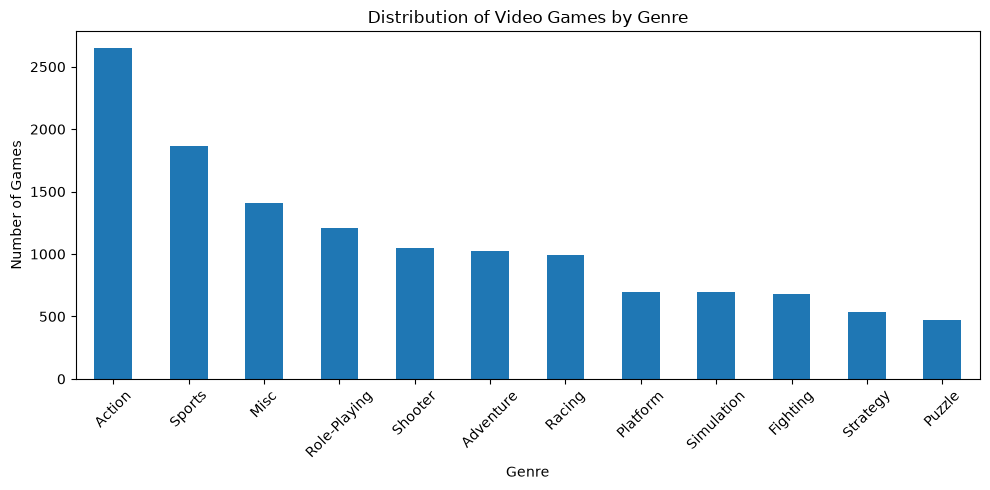

In [9]:
print("Genre distribution:")
print(Xtr["Genre"].value_counts())

print("\nTop 10 Publishers:")
print(Xtr["Publisher"].value_counts().head(10))

Xtr["Genre"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.title("Distribution of Video Games by Genre")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
## 8. Feature engineering

# Publisher frequency: I created a publisher_frequency feature
# representing how frequently each publisher appears in the
# training data because publishers with a larger presence
# in the market may have different sales performance.

# Learn publisher frequencies from TRAINING data only.
publisher_frequency = Xtr["Publisher"].value_counts()

Xtr["publisher_frequency"] = (
    Xtr["Publisher"].map(publisher_frequency).fillna(0)
)

Xte["publisher_frequency"] = (
    Xte["Publisher"].map(publisher_frequency).fillna(0)
)

# Look at the new feature
print(
    Xtr[
        ["Genre", "Publisher", "publisher_frequency"]
    ].head()
)

              Genre        Publisher  publisher_frequency
14303          Misc     Myelin Media                    2
13455    Simulation          Ubisoft                  718
6724         Action             Sega                  514
898      Simulation  Electronic Arts                 1079
8484   Role-Playing      Square Enix                  187


In [11]:
print(Xtr.columns.tolist())

['Genre', 'Publisher', 'publisher_frequency']


In [12]:
## 9. Encoding categorical variables

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Genre and Publisher have no meaningful order,
# so they are treated as nominal variables.
nominal_cols = ["Genre", "Publisher"]

nominal_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Learn the categories from training data only.
train_nominal = pd.DataFrame(
    nominal_encoder.fit_transform(Xtr[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols),
    index=Xtr.index
)

# Apply the same encoding to test data.
test_nominal = pd.DataFrame(
    nominal_encoder.transform(Xte[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols),
    index=Xte.index
)

# Replace the original categorical columns with encoded columns.
Xtr = pd.concat(
    [Xtr.drop(columns=nominal_cols + ["publisher_frequency"]), train_nominal],
    axis=1
)

Xte = pd.concat(
    [Xte.drop(columns=nominal_cols + ["publisher_frequency"]), test_nominal],
    axis=1
)

print("Columns after encoding:", Xtr.shape[1])

Columns after encoding: 548


In [13]:
## 10. Scaling numerical variables

from sklearn.preprocessing import StandardScaler

# Genre and Publisher are categorical variables.
# After one-hot encoding, their values are already 0 or 1.
# Therefore, numerical scaling is not required.

numeric_cols = []

print("Numerical variables requiring scaling:", numeric_cols)
print("Training data shape:", Xtr.shape)
print("Test data shape:", Xte.shape)

Numerical variables requiring scaling: []
Training data shape: (13278, 548)
Test data shape: (3320, 548)


In [14]:
## 11. Doing the same preparation with a pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Assign each column to the preprocessing it needs.
nominal_cols = ["Genre", "Publisher"]

# NOMINAL:
# Label missing categories as Unknown,
# then create 0/1 columns for each category.
nominal_pipeline = Pipeline([
    ("impute", SimpleImputer(
        strategy="constant",
        fill_value="Unknown"
    )),
    ("encode", OneHotEncoder(
        handle_unknown="ignore"
    )),
])

# Send categorical variables through preprocessing.
preprocessor = ColumnTransformer([
    ("nom", nominal_pipeline, nominal_cols),
])

# Complete preprocessing pipeline.
preprocessing_pipeline = Pipeline([
    ("preprocess", preprocessor),
])

# Learn categories from TRAINING data.
X_train_prepared = preprocessing_pipeline.fit_transform(
    X_train
)

# Apply the same transformation to test data.
X_test_prepared = preprocessing_pipeline.transform(
    X_test
)

print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)


Prepared train shape: (13278, 548)
Prepared test shape: (3320, 548)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

In [16]:
print('Shape:', df.shape)

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isna().sum())

df.describe().round(2)

Shape: (16598, 11)

Data types:
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16327.00,16598.00,16598.00,16598.00,16598.00,16598.00
mean,8300.61,2006.41,0.26,0.15,0.08,0.05,0.54
std,4791.85,5.83,0.82,0.51,0.31,0.19,1.56
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4151.25,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8300.50,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12449.75,2010.00,0.24,0.11,0.04,0.04,0.47
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74


In [17]:
# Research Question 2:
# Can we predict North American Sales from
# European and Japanese Sales?

# Target = North American sales
y = df_clean["NA_Sales"]

# Simple linear regression: EU sales only
X = df_clean[["EU_Sales"]]

# Remove rows with missing values
valid_rows = X.notna().all(axis=1) & y.notna()

X = X.loc[valid_rows]
y = y.loc[valid_rows]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train simple regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (16598, 1)
y shape: (16598,)


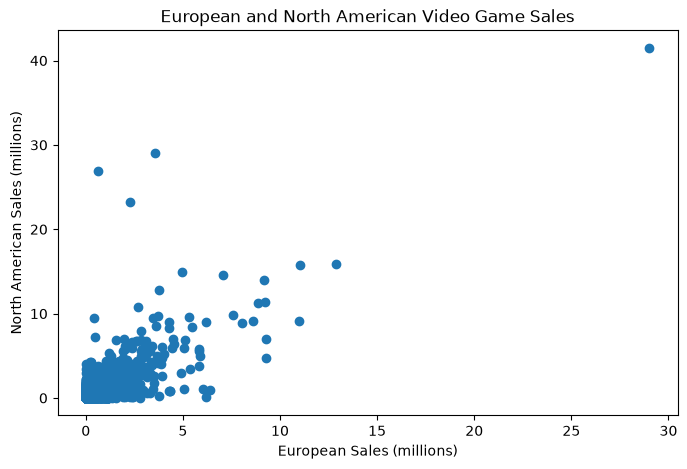

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df['EU_Sales'], df['NA_Sales'])

plt.xlabel('European Sales (millions)')
plt.ylabel('North American Sales (millions)')
plt.title('European and North American Video Game Sales')

plt.show()

In [19]:
## 7. Train vs. test data

# Split the data: 80% training and 20% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 13278
Test observations: 3320


In [20]:
# Multiple regression using European and Japanese sales
features = ["EU_Sales", "JP_Sales"]

X_multi = df_clean[features]
y_multi = df_clean["NA_Sales"]

# Remove rows with missing values
valid_rows = X_multi.notna().all(axis=1) & y_multi.notna()

X_multi = X_multi.loc[valid_rows]
y_multi = y_multi.loc[valid_rows]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

model_multi = LinearRegression()

model_multi.fit(X_train_m, y_train_m)

y_pred_m = model_multi.predict(X_test_m)


In [21]:
print(
    f"Simple model equation: NA_Sales = {model.intercept_:.3f} "
    f"+ {model.coef_[0]:.3f} × EU_Sales"
)

print(
    f"Multiple model equation: NA_Sales = {model_multi.intercept_:.3f} "
    f"+ {model_multi.coef_[0]:.3f} × EU_Sales "
    f"+ {model_multi.coef_[1]:.3f} × JP_Sales"
)

Simple model equation: NA_Sales = 0.090 + 1.191 × EU_Sales
Multiple model equation: NA_Sales = 0.074 + 1.049 × EU_Sales + 0.469 × JP_Sales


In [22]:
# Predictions from the multiple regression model
y_pred_m = model_multi.predict(X_test_m)

results = pd.DataFrame({
    "EU_Sales": X_test_m["EU_Sales"].values,
    "JP_Sales": X_test_m["JP_Sales"].values,
    "actual_NA_sales": y_test_m.values,
    "predicted_NA_sales": y_pred_m.round(2)
})

results.head(10)

,EU_Sales,JP_Sales,actual_NA_sales,predicted_NA_sales
0,0.11,0.00,0.01,0.19
1,0.04,0.01,0.32,0.12
2,0.02,0.00,0.00,0.10
3,0.01,0.00,0.01,0.08
4,0.11,0.00,0.20,0.19
5,0.71,0.22,1.19,0.92
6,0.17,0.01,0.18,0.26
7,0.04,0.00,0.56,0.12
8,0.04,0.00,0.17,0.12
9,0.00,0.44,0.00,0.28


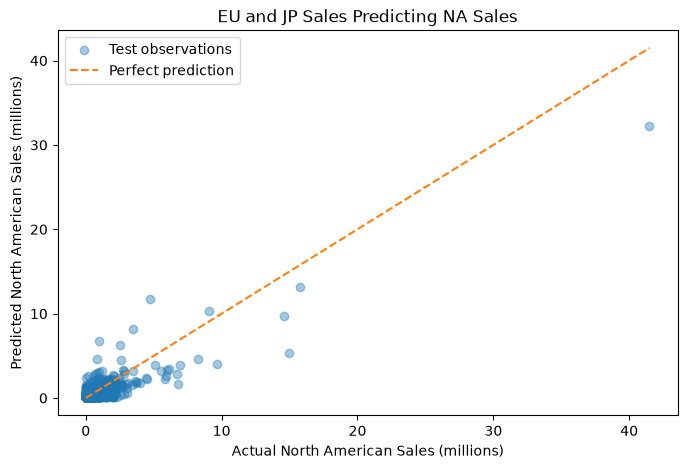

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_m,
    y_pred_m,
    alpha=0.4,
    label="Test observations"
)

limits = [
    min(y_test_m.min(), y_pred_m.min()),
    max(y_test_m.max(), y_pred_m.max())
]

plt.plot(
    limits,
    limits,
    color="C1",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual North American Sales (millions)")
plt.ylabel("Predicted North American Sales (millions)")
plt.title("EU and JP Sales Predicting NA Sales")

plt.legend()
plt.show()

In [24]:
results["residual"] = (
    y_test_m.values - y_pred_m
).round(2)

results.head(10)

,EU_Sales,JP_Sales,actual_NA_sales,predicted_NA_sales,residual
0,0.11,0.00,0.01,0.19,-0.18
1,0.04,0.01,0.32,0.12,0.20
2,0.02,0.00,0.00,0.10,-0.10
3,0.01,0.00,0.01,0.08,-0.07
4,0.11,0.00,0.20,0.19,0.01
5,0.71,0.22,1.19,0.92,0.27
6,0.17,0.01,0.18,0.26,-0.08
7,0.04,0.00,0.56,0.12,0.44
8,0.04,0.00,0.17,0.12,0.05
9,0.00,0.44,0.00,0.28,-0.28


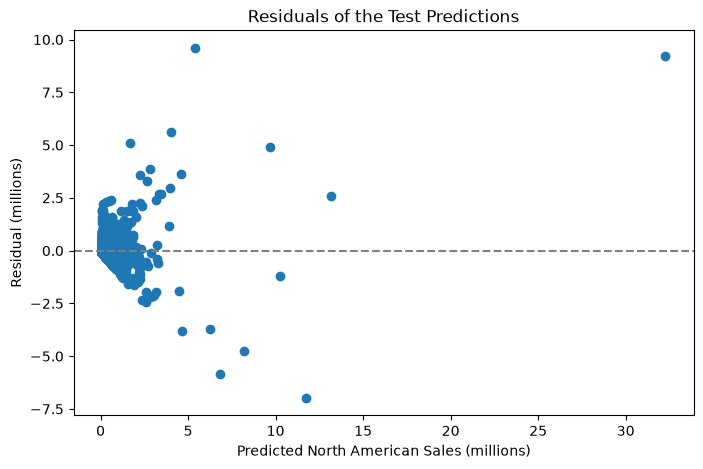

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    results['predicted_NA_sales'],
    results['residual']
)

plt.axhline(0, linestyle='--', color='grey')

plt.xlabel('Predicted North American Sales (millions)')
plt.ylabel('Residual (millions)')
plt.title('Residuals of the Test Predictions')

plt.show()

In [26]:
train_predictions = model_multi.predict(X_train_m)

train_residuals = y_train_m.values - train_predictions

train_sse = np.sum(train_residuals ** 2)

print(f"Training sum of squared errors: {train_sse:,.2f}")

Training sum of squared errors: 3,571.50


In [27]:
def regression_metrics(y_true, y_hat):
    mse = mean_squared_error(y_true, y_hat)

    return {
        'MAE (millions)': mean_absolute_error(y_true, y_hat),
        'MSE (millions²)': mse,
        'RMSE (millions)': np.sqrt(mse),
        'R²': r2_score(y_true, y_hat),
    }



metrics_multi = pd.DataFrame({
    "Training": regression_metrics(
        y_train_m,
        model_multi.predict(X_train_m)
    ),
    "Test": regression_metrics(
        y_test_m,
        y_pred_m
    ),
})

print(metrics_multi.round(3))

                 Training   Test
MAE (millions)      0.184  0.195
MSE (millions²)     0.269  0.248
RMSE (millions)     0.519  0.498
R²                  0.524  0.770


In [28]:
# Multiple regression using European and Japanese sales
features = ['EU_Sales', 'JP_Sales']

X_multi = df[features]
y_multi = df['NA_Sales']

# Remove rows with missing values
valid_rows = X_multi.notna().all(axis=1) & y_multi.notna()

X_multi = X_multi.loc[valid_rows]
y_multi = y_multi.loc[valid_rows]

# Split into training and test sets
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

# Train multiple linear regression model
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Make predictions
y_pred_m = model_multi.predict(X_test_m)


# Compare simple and multiple regression

comparison = pd.DataFrame({
    "EU Sales only (test)": regression_metrics(
        y_test,
        y_pred
    ),
    "EU + JP Sales (test)": regression_metrics(
        y_test_m,
        y_pred_m
    ),
})

comparison.drop(index="MSE (millions²)").round(3)

,EU Sales only (test),EU + JP Sales (test)
MAE (millions),0.188,0.195
RMSE (millions),0.478,0.498
R²,0.787,0.770


In [29]:
learned = pd.Series(
    model_multi.coef_,
    index=X_train_m.columns
)

print("Intercept:", round(model_multi.intercept_, 3))

learned_coefficients = pd.DataFrame({
    'Learned coefficient': learned.round(3)
})

learned_coefficients

Intercept: 0.074


,Learned coefficient
EU_Sales,1.049
JP_Sales,0.469


In [30]:
print(
    f"Correlation between EU Sales and NA Sales: "
    f"{df['EU_Sales'].corr(df['NA_Sales']):.2f}"
)

print(
    f"Correlation between JP Sales and NA Sales: "
    f"{df['JP_Sales'].corr(df['NA_Sales']):.2f}"
)

print(
    f"Correlation between EU Sales and JP Sales: "
    f"{df['EU_Sales'].corr(df['JP_Sales']):.2f}"
)

Correlation between EU Sales and NA Sales: 0.77
Correlation between JP Sales and NA Sales: 0.45
Correlation between EU Sales and JP Sales: 0.44


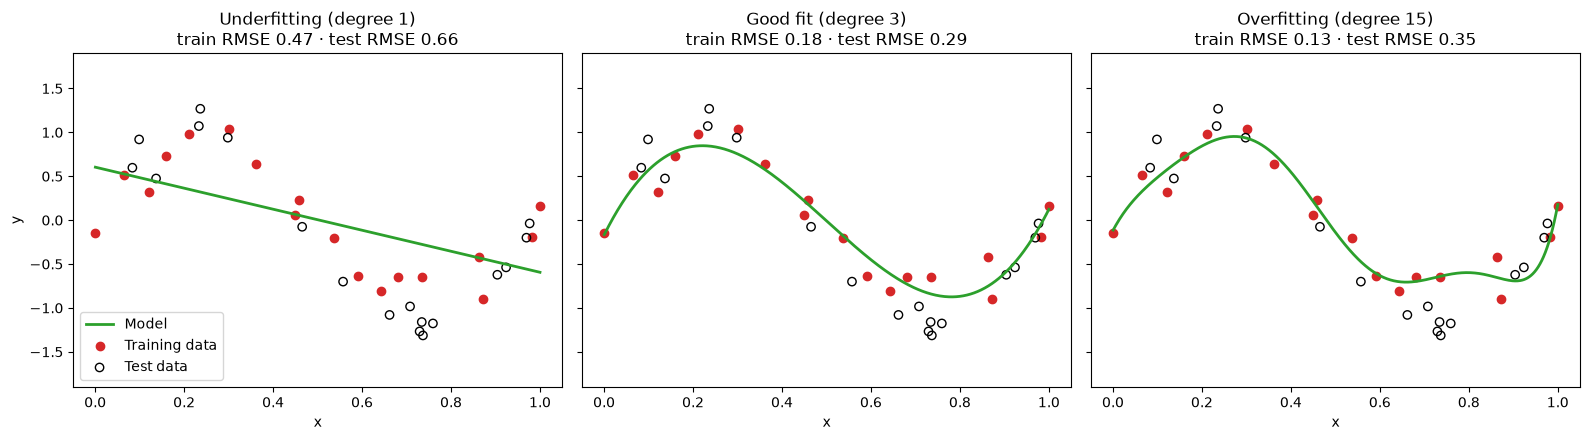

In [31]:
toy_rng = np.random.default_rng(39)
true_curve = lambda x: np.sin(2 * np.pi * x)

x_toy_train = np.sort(
    np.clip(
        np.linspace(0, 1, 18) + toy_rng.normal(0, 0.02, 18),
        0,
        1
    )
)

y_toy_train = (
    true_curve(x_toy_train)
    + toy_rng.normal(0, 0.25, 18)
)

x_toy_test = np.sort(
    toy_rng.uniform(
        x_toy_train.min(),
        x_toy_train.max(),
        18
    )
)

y_toy_test = (
    true_curve(x_toy_test)
    + toy_rng.normal(0, 0.25, 18)
)


def poly_model(degree):
    return make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ).fit(
        x_toy_train[:, None],
        y_toy_train
    )


def rmse(m, x, y_true):
    return np.sqrt(
        mean_squared_error(
            y_true,
            m.predict(x[:, None])
        )
    )


x_grid = np.linspace(
    x_toy_train.min(),
    x_toy_train.max(),
    500
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
    sharey=True
)

for ax, (degree, label) in zip(
    axes,
    [
        (1, 'Underfitting'),
        (3, 'Good fit'),
        (15, 'Overfitting')
    ]
):
    m = poly_model(degree)

    ax.plot(
        x_grid,
        m.predict(x_grid[:, None]),
        color='C2',
        lw=2,
        label='Model'
    )

    ax.scatter(
        x_toy_train,
        y_toy_train,
        color='C3',
        label='Training data'
    )

    ax.scatter(
        x_toy_test,
        y_toy_test,
        facecolors='none',
        edgecolors='k',
        label='Test data'
    )

    ax.set_ylim(-1.9, 1.9)

    ax.set_title(
        f'{label} (degree {degree})\n'
        f'train RMSE {rmse(m, x_toy_train, y_toy_train):.2f} · '
        f'test RMSE {rmse(m, x_toy_test, y_toy_test):.2f}'
    )

    ax.set_xlabel('x')

axes[0].set_ylabel('y')
axes[0].legend(loc='lower left')

plt.tight_layout()
plt.show()

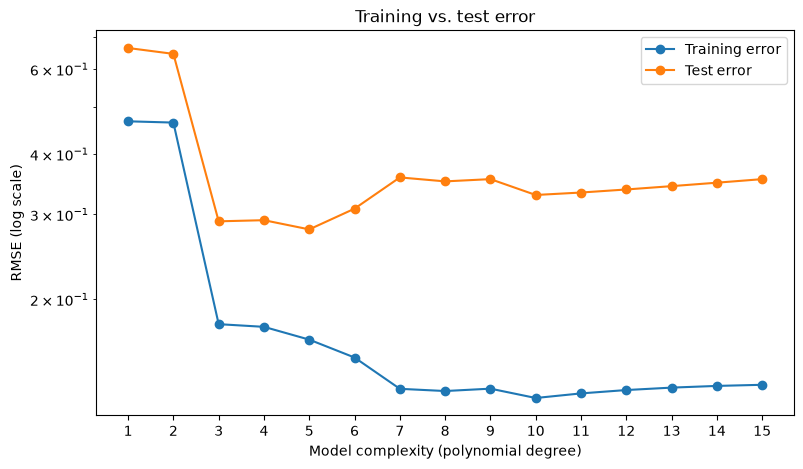

In [32]:
degrees = range(1, 16)

train_err = [
    rmse(poly_model(d), x_toy_train, y_toy_train)
    for d in degrees
]

test_err = [
    rmse(poly_model(d), x_toy_test, y_toy_test)
    for d in degrees
]

plt.figure(figsize=(9, 5))

plt.plot(
    degrees,
    train_err,
    'o-',
    label='Training error'
)

plt.plot(
    degrees,
    test_err,
    'o-',
    label='Test error'
)

plt.yscale('log')
plt.xticks(list(degrees))

plt.xlabel('Model complexity (polynomial degree)')
plt.ylabel('RMSE (log scale)')
plt.title('Training vs. test error')

plt.legend()
plt.show()